# Mall_Customer_Segmentation (Unsupervised Learning)

Unsupervised ML is when you don’t have a target label (y) and you want the model to discover structure in the data (X) on its own.

# Common goals:

Clustering: group similar data points (K-Means, Hierarchical, DBSCAN, GMM)

Dimensionality reduction: compress features while keeping information (PCA, t-SNE, UMAP)

Anomaly detection: find rare/outlier patterns (Isolation Forest, One-Class SVM)

Association rules: “people who buy X also buy Y” (Apriori, FP-Growth)

In our project (Mall Customers), it’s clustering: group customers by Annual Income + Spending Score.

## Why we often don’t need a train/test split in unsupervised learning ?

In supervised learning, you split because you must measure generalization: “Does the model predict correct labels on unseen data?”

In unsupervised learning, there are no ground-truth labels to score against, so a classic accuracy-style test set evaluation doesn’t apply.

Instead, you typically validate using:

Internal clustering metrics (no labels needed):

1. Silhouette score

2. Davies–Bouldin index

3. Calinski–Harabasz

Stability checks: do clusters remain similar if you resample the data or change random seed?

Business validation: do segments make sense and lead to better actions (targeting, offers, retention)?


In [1]:
# Customer Segmentation using K-Means (end-to-end)
# ------------------------------------------------
# 1) Load dataset
# 2) Basic EDA
# 3) Select features (Annual Income, Spending Score)
# 4) Train KMeans (default + explain)
# 5) Elbow method to pick K
# 6) Train final KMeans with K=5
# 7) Visualize clusters + centroids
# 8) Predict new customer cluster
# 9) Save + load model using joblib


In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import joblib

In [97]:
# 1) Load dataset
# ----------------------------
# Make sure Mall_Customers.csv (or mall_customers.csv) is in the same folder as this notebook/script.
# Kaggle dataset often uses "Mall_Customers.csv"
data = pd.read_csv("Mall_Customers.csv")  # or "mall_customers.csv"
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [99]:
# 2) Basic EDA top,last rows , information & null values
# ----------------------------
print("Top 5 rows:")
print(data.head())

print("\nLast 5 rows:")
print(data.tail())

print("\nShape (rows, cols):", data.shape)
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nInfo:")
print(data.info())

print("\nNull values per column:")
print(data.isnull().sum())

print("\nDescribe (numeric columns):")
print(data.describe())

print("\nColumns:")
print(data.columns)


Top 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Last 5 rows:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

Shape (rows, cols): (200, 5)
Number of rows: 200
Number of columns: 5

Info:
<class 'pandas.core.frame.DataFr

# Feature selection (2 columns for easy visualization)


In [101]:
# 3) Select features (Annual Income, Spending Score)
# Kaggle column names are usually:
# 'Annual Income (k$)' and 'Spending Score (1-100)'
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]


In this project, the dataset had multiple columns (CustomerID, Gender, Age, Annual Income, Spending Score), but we intentionally chose only:

1. Annual Income
2. Spending Score

and dropped the rest for the clustering step.

That choice is feature selection because we're deciding which variables the model is allowed to use to form clusters.

Why that counts as feature selection here ?

CustomerID is just an identifier → it would create nonsense clusters.

Gender/Age might be useful, but the video’s goal was easy 2D visualization and a simple demo.

Using only 2 features makes clusters easy to interpret and plot.   '''

In [15]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


# K-Means Clustering
Noon-distance based model

In [103]:
# 4) Train KMeans (default + explain)
# KMeans default training (shows default clusters=8 in sklearn)
# ----------------------------
k_means = KMeans()  # default n_clusters=8 (depends on sklearn version)
k_means.fit(X)
# to train model on X we use .fit

C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans()

In [105]:
k_means = KMeans(n_clusters = 5)
k_means.fit_predict(X)
# to identify no.of clusters we use fit_predict

C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 2,
       0, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 1, 2, 1, 3, 1, 3, 1,
       2, 1, 3, 1, 3, 1, 3, 1, 3, 1, 2, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

 # Elbow method (WCSS = inertia)
 Within-Cluster Sum of Squares (WCSS)

C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

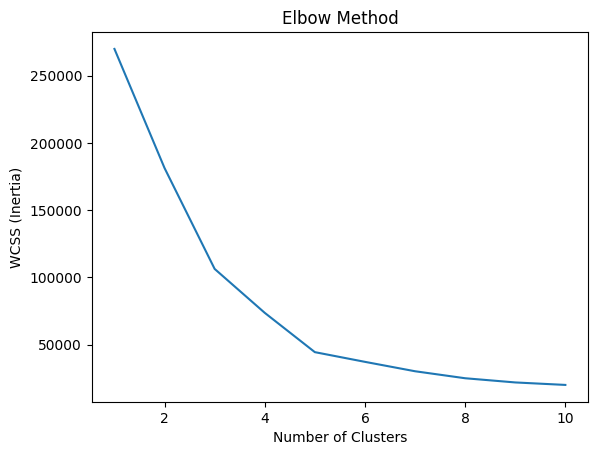

In [107]:
# 5) Elbow method to pick K
wcss = []
for i in range(1, 11):
    k_means = KMeans(n_clusters=i, random_state=42)
    k_means.fit(X)
    wcss.append(k_means.inertia_)  # inertia = WCSS

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Inertia)")
plt.plot(range(1, 11), wcss)
plt.show()



## WCSS vs Inertia in K-Means

In **K-Means**, **WCSS** and **inertia** are basically the same thing. WCSS = concept , inertia_ = scikit-learn’s variable name for WCSS

---

### WCSS (Within-Cluster Sum of Squares)

WCSS measures how **tight/compact** the clusters are.

For each cluster:

1. Take every point in that cluster  
2. Compute the **squared distance** from the point to the **cluster centroid**  
3. Sum those squared distances  
4. Then add that across all clusters  

So:

$$
\text{WCSS} = \sum_{k=1}^{K}\sum_{x \in C_k} \|x - \mu_k\|^2
$$

Where:
- $C_k$ = points in cluster $k$
- $\mu_k$ = centroid of cluster $k$
- $\|x - \mu_k\|^2$ = squared Euclidean distance

**Lower WCSS ⇒ clusters are more compact.**



Why elbow method uses WCSS/inertia ?

When you increase K:

clusters get smaller,points are closer to a centroid,so WCSS/inertia always decreases. But after some point, adding more clusters gives only a small improvement (diminishing returns). That bend is the “elbow”.

One important limitation

Because inertia always goes down as K increases, it cannot “prove” the best K by itself. That’s why people also check:

silhouette score

cluster stability

business interpretability

In [131]:
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [133]:
# 6) Train final KMeans with K=5
# Based on the usual elbow in this dataset, we pick 5

k_means = KMeans(n_clusters= 5, random_state=42)
y_means = k_means.fit_predict(X)


C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dipes\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [135]:
y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

# Silhouette Score

In [137]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X, y_means)
print("Silhouette score (k=5):", sil)

Silhouette score (k=5): 0.553931997444648


What silhouette score helps you understand

Silhouette score tells you how good your clustering is by checking two things for every point:

a = how close the point is to other points in its own cluster (cohesion)

b = how far the point is from points in the nearest other cluster (separation)

Silhouette for one point:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
$$


So overall silhouette score (average of all points) means:

Close to 1 → clusters are well separated and points sit nicely inside their clusters ✅

Around 0 → clusters are overlapping (boundaries are messy) 😐

Negative → many points might be in the wrong cluster ❌

What that means (in simple terms)

It’s a “good / decent” clustering, not perfect.

Your clusters are reasonably separated, and points are mostly closer to their own cluster than to the nearest other cluster.

Some overlap still exists (which is normal for real customer data).

How to interpret the scale

0.70 – 1.00: very strong, clearly separated clusters ✅

0.50 – 0.70: decent/good clustering ✅ (you are here)

0.25 – 0.50: weak/moderate separation 😐

0.00 – 0.25: heavy overlap 😕

< 0: many points likely assigned to wrong clusters ❌

What you can conclude for your project

✅ K=5 is reasonable for this dataset (your clusters have real structure).
✅ Your segmentation can be used for marketing/customer strategy.
⚠️ But cluster borders are not razor-sharp — a few customers sit between segments.

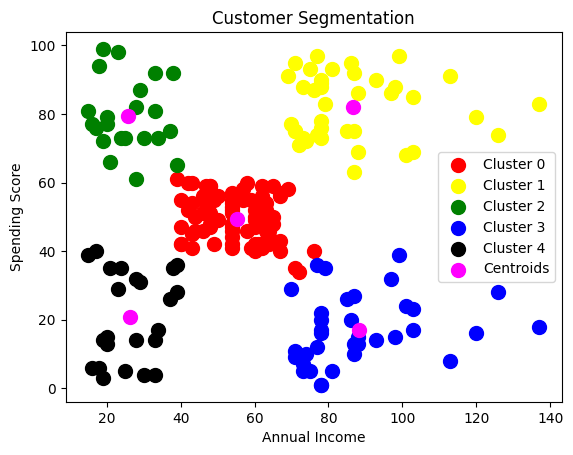

In [117]:
# 7) Visualize clusters
plt.scatter(X.iloc[y_means==0, 0], X.iloc[y_means==0, 1], s=100, c='red',    label="Cluster 0")
plt.scatter(X.iloc[y_means==1, 0], X.iloc[y_means==1, 1], s=100, c='yellow', label="Cluster 1")
plt.scatter(X.iloc[y_means==2, 0], X.iloc[y_means==2, 1], s=100, c='green',  label="Cluster 2")
plt.scatter(X.iloc[y_means==3, 0], X.iloc[y_means==3, 1], s=100, c='blue',   label="Cluster 3")
plt.scatter(X.iloc[y_means==4, 0], X.iloc[y_means==4, 1], s=100, c='black',  label="Cluster 4")

# centroids
plt.scatter(k_means.cluster_centers_[:, 0], k_means.cluster_centers_[:, 1], s=100, c='magenta', label="Centroids")

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

1. Yellow (top-right-ish): higher spenders (generally medium–high income + high spending)

2. Blue (bottom-right): high income but low spending (rich but not shopping much)

3. Green (top-left): low income but high spending (spend a lot despite low income)

4. Black (bottom-left): low income, low spending (budget/low activity)

5. Red (middle): average/medium income and medium spending (mainstream customers)

Business takeaway: marketing can target each segment differently (premium offers for high spenders, discounts/engagement for low spenders, etc.).

Centroids:

Our model’s cluster_centers_ are:

0 → (55.30, 49.52) = medium income, medium spend

1 → (86.54, 82.13) = high income, high spend

2 → (25.73, 79.36) = low income, high spend

3 → (88.20, 17.11) = high income, low spend

4 → (26.30, 20.91) = low income, low spend

In [64]:
# 8) Predict new customer cluster
k_means.predict([[15,39]]) # 15 - annual income 39 - spending score

C:\Users\dipes\anaconda3\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4])

Annual income = 15 → very low (left side of the plot)

Spending score = 39 → low-to-mid (lower half)

On our chart, that point would fall closest to the bottom-left region (the low income / low spending segment). In your labeling, the model returned array([4]), which means it assigned it to cluster index 4 (our “Cluster 5” label as shown Cluster 1–5 in the legend).

In [66]:
# 9) Save + load model using joblib
import joblib

In [68]:
joblib.dump(k_means,"customer_segmentation")

['customer_segmentation']

In [72]:
model = joblib.load("customer_segmentation") # model name

In [74]:
model.predict([[15,39]])

C:\Users\dipes\anaconda3\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4])

# GUI

In [119]:
from tkinter import *
import joblib

def show_entry_fields():
    p1 = int(e1.get())
    p2 = int(e2.get())

    model = joblib.load('customer_segmentation')  # update filename if needed
    result = model.predict([[p1, p2]])
    print("This Customer belongs to cluster no: ", result[0])

    if result[0] == 0:
        Label(master, text="Customers with medium annual income and medium annual spend").grid(row=5, column=0, columnspan=2)
    elif result[0] == 1:
        Label(master, text="Customers with high annual income and high annual spend").grid(row=5, column=0, columnspan=2)
    elif result[0] == 2:
        Label(master, text= "Customers with low annual income but high annual spend").grid(row=5, column=0, columnspan=2)
    elif result[0] == 3:
        Label(master, text="Customers with high annual income but low annual spend").grid(row=5, column=0, columnspan=2)
    elif result[0] == 4:
        Label(master, text="Customers with low annual income and low annual spend").grid(row=5, column=0, columnspan=2)

master = Tk()
master.title("Customer Segmentation Using Machine Learning")

label = Label(master, text="Customer Segmentation Using Machine Learning by Aayush Gautam", bg="black", fg="white").grid(row=0, columnspan=2)

Label(master, text="Annual Income").grid(row=1)
Label(master, text="Spending Score").grid(row=2)

e1 = Entry(master)
e2 = Entry(master)

e1.grid(row=1, column=1)
e2.grid(row=2, column=1)

Button(master, text='Predict', command=show_entry_fields).grid(row=3, column=0, columnspan=2)

mainloop()

C:\Users\dipes\anaconda3\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


This Customer belongs to cluster no:  4
